IMPORT DEPENDENCIES





In [91]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pickle

LOAD DATASETS

In [92]:
with open("/content/drive/MyDrive/MLworks/HeatWaveHealthRiskPrediction/data/climate_sri_lanka (3).csv", "r") as f:
    lines = f.readlines()

cleaned = [line.strip().strip('"') for line in lines]

with open("cleaned_climate.csv", "w") as f:
    for line in cleaned:
        f.write(line + "\n")

climate_df = pd.read_csv("cleaned_climate.csv")
print(climate_df.head())




with open("/content/drive/MyDrive/MLworks/HeatWaveHealthRiskPrediction/data/health_sri_lanka (3).csv", "r") as f:
    lines = f.readlines()

cleaned = [line.strip().strip('"') for line in lines]

with open("cleaned_health.csv", "w") as f:
    for line in cleaned:
        f.write(line + "\n")

health_df = pd.read_csv("cleaned_health.csv")
print(health_df.head())

         Date  Climate_ID      District  Temperature_C  Humidity_%  \
0  2021-01-01         1.0         Galle           26.9        77.9   
1  2021-01-02         2.0  Anuradhapura           29.7        76.3   
2  2021-01-03         3.0   Trincomalee           26.1        73.0   
3  2021-01-04         4.0   Kilinochchi           29.7        74.7   
4  2021-01-05         5.0        Matara           28.1        86.4   

   Rainfall_mm  Wind_Speed_kmh  Heat_Index  
0          2.4            13.5         NaN  
1          6.4            21.8        35.8  
2          NaN            13.2         NaN  
3          1.3            26.0        35.4  
4          3.1             5.0         NaN  
   Person_ID Admitted_Date   Age Gender  Heart_Disease  Diabetes  \
0        1.0    2021-01-15  38.0      F            NaN       0.0   
1        2.0    2023-01-28  30.0      M            1.0       0.0   
2        3.0    2022-11-19  34.0      F            0.0       0.0   
3        4.0    2021-01-04   NaN     

UNDERSTAND THE DATA

In [93]:
climate_df.head()

,Date,Climate_ID,District,Temperature_C,Humidity_%,Rainfall_mm,Wind_Speed_kmh,Heat_Index
0,2021-01-01,1.0,Galle,26.9,77.9,2.4,13.5,NaN
1,2021-01-02,2.0,Anuradhapura,29.7,76.3,6.4,21.8,35.8
2,2021-01-03,3.0,Trincomalee,26.1,73.0,NaN,13.2,NaN
3,2021-01-04,4.0,Kilinochchi,29.7,74.7,1.3,26.0,35.4
4,2021-01-05,5.0,Matara,28.1,86.4,3.1,5.0,NaN


In [94]:
health_df.head()

,Person_ID,Admitted_Date,Age,Gender,Heart_Disease,Diabetes,Respiratory_Issue,Outdoor_Worker,Systolic_BP,Diastolic_BP,Hydration_Level
0,1.0,2021-01-15,38.0,F,NaN,0.0,0.0,0.0,123.0,78.0,Moderate
1,2.0,2023-01-28,30.0,M,1.0,0.0,0.0,0.0,135.0,89.0,Moderate
2,3.0,2022-11-19,34.0,F,0.0,0.0,0.0,0.0,127.0,69.0,High
3,4.0,2021-01-04,NaN,F,0.0,NaN,0.0,1.0,132.0,NaN,Low
4,5.0,2024-10-31,46.0,F,0.0,0.0,0.0,1.0,118.0,NaN,Moderate


In [95]:
# Drop the specified columns from climate dataset
climate_df = climate_df.drop(['Climate_ID', 'District', 'Heat_Index'], axis=1)

# Verify the columns have been dropped
print("Climate dataset columns after dropping:")
print(climate_df.columns.tolist())

print("\nClimate dataset preview:")
print(climate_df.head())

# Check the new shape
print(f"\nNew climate dataset shape: {climate_df.shape}")

Climate dataset columns after dropping:
['Date', 'Temperature_C', 'Humidity_%', 'Rainfall_mm', 'Wind_Speed_kmh']

Climate dataset preview:
         Date  Temperature_C  Humidity_%  Rainfall_mm  Wind_Speed_kmh
0  2021-01-01           26.9        77.9          2.4            13.5
1  2021-01-02           29.7        76.3          6.4            21.8
2  2021-01-03           26.1        73.0          NaN            13.2
3  2021-01-04           29.7        74.7          1.3            26.0
4  2021-01-05           28.1        86.4          3.1             5.0

New climate dataset shape: (1500, 5)


In [96]:
# Display first few rows
print("Climate Dataset - First 5 rows:")
print(climate_df.head())
print("\n" + "="*50 + "\n")

print("Health Dataset - First 5 rows:")
print(health_df.head())
print("\n" + "="*50 + "\n")

# Display dataset information
print("Climate Dataset Info:")
print(climate_df.info())
print("\n" + "="*50 + "\n")

print("Health Dataset Info:")
print(health_df.info())
print("\n" + "="*50 + "\n")

# Remove rows with null values in specific columns
climate_df.dropna(inplace=True)
health_df.dropna(inplace=True)

# Fill remaining numeric null values with mean (climate dataset)
numeric_cols = climate_df.select_dtypes(include=['number']).columns
climate_df[numeric_cols] = climate_df[numeric_cols].fillna(climate_df[numeric_cols].mean())

# Fill remaining null values with 0 (health dataset)
health_df.fillna(0, inplace=True)

# Verify the null values have been removed
print("\nClimate dataset null values after cleaning:")
print(climate_df.isnull().sum())

print("\nHealth dataset null values after cleaning:")
print(health_df.isnull().sum())

# Check the new shape of the datasets
print(f"\nOriginal climate dataset shape: {climate_df_clean.shape if 'climate_df_clean' in dir() else climate_df.shape}")
print(f"Cleaned climate dataset shape: {climate_df.shape}")
print(f"Original health dataset shape: {health_df_clean.shape if 'health_df_clean' in dir() else health_df.shape}")
print(f"Cleaned health dataset shape: {health_df.shape}")

# If you want to create separate cleaned DataFrames
climate_df_clean = climate_df.copy()
health_df_clean = health_df.copy()

print("\n✅ Data cleaning completed successfully!")
print(f"Climate cleaned shape: {climate_df_clean.shape}")
print(f"Health cleaned shape: {health_df_clean.shape}")

Climate Dataset - First 5 rows:
         Date  Temperature_C  Humidity_%  Rainfall_mm  Wind_Speed_kmh
0  2021-01-01           26.9        77.9          2.4            13.5
1  2021-01-02           29.7        76.3          6.4            21.8
2  2021-01-03           26.1        73.0          NaN            13.2
3  2021-01-04           29.7        74.7          1.3            26.0
4  2021-01-05           28.1        86.4          3.1             5.0


Health Dataset - First 5 rows:
   Person_ID Admitted_Date   Age Gender  Heart_Disease  Diabetes  \
0        1.0    2021-01-15  38.0      F            NaN       0.0   
1        2.0    2023-01-28  30.0      M            1.0       0.0   
2        3.0    2022-11-19  34.0      F            0.0       0.0   
3        4.0    2021-01-04   NaN      F            0.0       NaN   
4        5.0    2024-10-31  46.0      F            0.0       0.0   

   Respiratory_Issue  Outdoor_Worker  Systolic_BP  Diastolic_BP  \
0                0.0             0.0   

In [97]:
merged_df = pd.merge(
    health_df,
    climate_df,
    left_on='Admitted_Date',
    right_on='Date',
    how='inner'
)

In [98]:
merged_df.head()


,Person_ID,Admitted_Date,Age,Gender,Heart_Disease,Diabetes,Respiratory_Issue,Outdoor_Worker,Systolic_BP,Diastolic_BP,Hydration_Level,Date,Temperature_C,Humidity_%,Rainfall_mm,Wind_Speed_kmh
0,3.0,2022-11-19,34.0,F,0.0,0.0,0.0,0.0,127.0,69.0,High,2022-11-19,32.6,78.3,0.0,11.8
1,6.0,2024-10-24,56.0,M,0.0,0.0,0.0,1.0,126.0,71.0,High,2024-10-24,30.9,70.3,3.9,11.4
2,13.0,2024-05-24,64.0,M,0.0,1.0,0.0,1.0,158.0,81.0,Moderate,2024-05-24,25.6,62.3,0.0,17.4
3,17.0,2024-06-23,64.0,M,0.0,0.0,0.0,1.0,124.0,86.0,Low,2024-06-23,30.1,82.2,0.0,21.4
4,22.0,2024-08-09,44.0,F,0.0,0.0,0.0,0.0,117.0,67.0,Moderate,2024-08-09,25.8,83.2,6.6,5.0


In [99]:
merged_df.shape

(500, 16)

In [100]:
merged_df['Hypertension'] = (
    (merged_df['Systolic_BP'] >= 140) |
    (merged_df['Diastolic_BP'] >= 90)
).astype(int)

DATA CLEANING & PREPROCESSING

In [101]:
merged_df['Heat_Index'] = (
    merged_df['Temperature_C'] +
    (0.12 * merged_df['Humidity_%'])
)

In [102]:
def assign_risk(row):

    disease_score = (
        row['Heart_Disease'] +
        row['Diabetes'] +
        row['Respiratory_Issue'] +
        row['Hypertension']
    )

    # HIGH RISK

    if (
        row['Heat_Index'] > 42 and
        (
            row['Age'] > 60 or
            disease_score >= 2 or
            row['Outdoor_Worker'] == 1
        )
    ):
        return "High"

    # MEDIUM RISK

    elif (
        row['Heat_Index'] >= 36 or
        disease_score >= 1 or
        row['Outdoor_Worker'] == 1
    ):
        return "Medium"

    # LOW RISK

    return "Low"

merged_df['Risk_Level'] = merged_df.apply(assign_risk, axis=1)

In [103]:
print(
    merged_df['Risk_Level'].value_counts()
)

Risk_Level
Medium    361
Low       139
Name: count, dtype: int64


In [104]:
merged_df.drop(
    columns=[
        'Person_ID',
        'Date',
        'Admitted_Date'
    ],
    inplace=True
)

In [105]:
merged_df.head()

,Age,Gender,Heart_Disease,Diabetes,Respiratory_Issue,Outdoor_Worker,Systolic_BP,Diastolic_BP,Hydration_Level,Temperature_C,Humidity_%,Rainfall_mm,Wind_Speed_kmh,Hypertension,Heat_Index,Risk_Level
0,34.0,F,0.0,0.0,0.0,0.0,127.0,69.0,High,32.6,78.3,0.0,11.8,0,41.996,Medium
1,56.0,M,0.0,0.0,0.0,1.0,126.0,71.0,High,30.9,70.3,3.9,11.4,0,39.336,Medium
2,64.0,M,0.0,1.0,0.0,1.0,158.0,81.0,Moderate,25.6,62.3,0.0,17.4,1,33.076,Medium
3,64.0,M,0.0,0.0,0.0,1.0,124.0,86.0,Low,30.1,82.2,0.0,21.4,0,39.964,Medium
4,44.0,F,0.0,0.0,0.0,0.0,117.0,67.0,Moderate,25.8,83.2,6.6,5.0,0,35.784,Low


In [106]:
merged_df['Gender'] = (
    merged_df['Gender']
    .map({
        'M': 1,
        'F': 0
    })
)

In [107]:
merged_df['Hydration_Level'] = (
    merged_df['Hydration_Level']
    .map({
        'Low': 0,
        'Moderate': 1,
        'Good': 2
    })
)

In [108]:
merged_df['Risk_Level'] = (
    merged_df['Risk_Level']
    .map({
        'Low': 0,
        'Medium': 1,
        'High': 2
    })
)

In [110]:
merged_df.head()

,Age,Gender,Heart_Disease,Diabetes,Respiratory_Issue,Outdoor_Worker,Systolic_BP,Diastolic_BP,Hydration_Level,Temperature_C,Humidity_%,Rainfall_mm,Wind_Speed_kmh,Hypertension,Heat_Index,Risk_Level
0,34.0,0,0.0,0.0,0.0,0.0,127.0,69.0,NaN,32.6,78.3,0.0,11.8,0,41.996,1
1,56.0,1,0.0,0.0,0.0,1.0,126.0,71.0,NaN,30.9,70.3,3.9,11.4,0,39.336,1
2,64.0,1,0.0,1.0,0.0,1.0,158.0,81.0,1.0,25.6,62.3,0.0,17.4,1,33.076,1
3,64.0,1,0.0,0.0,0.0,1.0,124.0,86.0,0.0,30.1,82.2,0.0,21.4,0,39.964,1
4,44.0,0,0.0,0.0,0.0,0.0,117.0,67.0,1.0,25.8,83.2,6.6,5.0,0,35.784,0


In [111]:
X = merged_df.drop(columns=['Risk_Level'])

y = merged_df['Risk_Level']

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [113]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [114]:
y_pred = model.predict(X_test)

In [115]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.98


In [116]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.97      1.00      0.99        70

    accuracy                           0.98       100
   macro avg       0.99      0.97      0.98       100
weighted avg       0.98      0.98      0.98       100



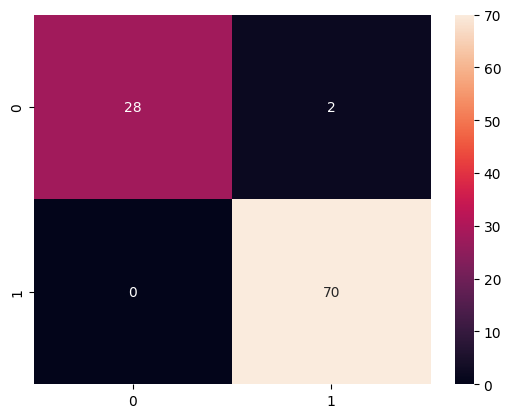

In [117]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.show()

In [118]:
importance = model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

              Feature  Importance
5      Outdoor_Worker    0.237849
14         Heat_Index    0.197661
9       Temperature_C    0.111365
6         Systolic_BP    0.079389
13       Hypertension    0.074896
4   Respiratory_Issue    0.063734
10         Humidity_%    0.042563
7        Diastolic_BP    0.041498
3            Diabetes    0.040064
0                 Age    0.037739
12     Wind_Speed_kmh    0.031882
11        Rainfall_mm    0.018259
8     Hydration_Level    0.011643
2       Heart_Disease    0.007202
1              Gender    0.004256


In [120]:
pickle.dump(
    model,
    open('/content/drive/MyDrive/MLworks/HeatWaveHealthRiskPrediction/models/risk_model.pkl', 'wb')
)